In [31]:
import pandas as pd
import numpy as np
import math
from matplotlib import pyplot as plt

In [32]:
data = pd.read_csv('../datasets/train.csv')

In [33]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
data.dtypes.count()

np.int64(785)

In [35]:
type(data)

pandas.core.frame.DataFrame

In [36]:
data = np.array(data)

In [37]:
data_y = data[:,0]
data_X = data[:,1:]

In [38]:
data_X = data_X.astype(np.float32) / 255.0

In [39]:
data_y.dtype

dtype('int64')

In [40]:
data_X.dtype

dtype('float32')

In [41]:
data_y = np.eye(10)[data_y]

In [42]:
m, n = data_X.shape

In [43]:
print(data_y)

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


In [44]:
shuffle_i = np.arange(m)

In [45]:
np.random.shuffle(shuffle_i)

In [46]:
data_X = data_X[shuffle_i]
data_y = data_y[shuffle_i]

# train/validation split (%80 - %20)
split_idx = int(0.8 * m)
X_train, X_val = data_X[:split_idx], data_X[split_idx:]
y_train, y_val = data_y[:split_idx], data_y[split_idx:]


In [47]:
print(data_X.shape)

(42000, 784)


In [48]:
def init_params():
    w1 = np.random.rand(784,128) - 0.5
    w2 = np.random.rand(128,10) - 0.5
    b1 = np.zeros((1, 128))
    b2 = np.zeros((1, 10))
    return w1,b1,w2,b2

In [49]:
def reLU(a):
    return np.maximum(0,a)
def sigmoid(a):
    return 1 / (1 + np.exp(-a))
def softmax(a):
    exp_a = np.exp(a - np.max(a, axis=1, keepdims=True))  # satır bazlı max çıkar
    return exp_a / np.sum(exp_a, axis=1, keepdims=True)   # satır bazlı normalize et


In [50]:
def forward_propagation(data_X,w1,b1,w2,b2):
    z1 = np.dot(data_X,w1) + b1
    a1 = reLU(z1)
    z2 = np.dot(a1,w2) + b2
    a2 = softmax(z2)
    return z1,a1,z2,a2

In [51]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    eps = 1e-8
    loss = -np.sum(y_true * np.log(y_pred + eps)) / m
    return loss

In [52]:
def relu_deriv(a):
    return (a > 0).astype(float)

In [53]:
def backward_propagation(z1, a1, z2, a2, w1, w2, X, y):
    m = X.shape[0]

    dz2 = a2 - y
    dw2 = np.dot(a1.T, dz2) / m
    db2 = np.mean(dz2, axis=0, keepdims=True)

    dz1 = np.dot(dz2, w2.T) * relu_deriv(z1)
    dw1 = np.dot(X.T, dz1) / m
    db1 = np.mean(dz1, axis=0, keepdims=True)

    return dw1, db1, dw2, db2

In [54]:
def update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,lrate):
    w1 = w1 - lrate * dw1
    b1 = b1 - lrate * db1
    w2 = w2 - lrate * dw2
    b2 = b2 - lrate * db2
    return w1,b1,w2,b2

In [55]:
def gradient_descent(X,y,lr,iterations):
    w1,b1,w2,b2 = init_params()
    for iter in range(iterations):
        z1,a1,z2,a2 = forward_propagation(X,w1,b1,w2,b2)
        loss = compute_loss(y,a2)
        dw1,db1,dw2,db2 = backward_propagation(z1,a1,z2,a2,w1,w2,X,y)
        w1,b1,w2,b2 = update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,lr)
        if iter % 10 == 0:
            y_pred = np.argmax(a2, axis=1)
            y_true = np.argmax(y, axis=1)
            accuracy = np.mean(y_pred == y_true)
            print(f"Epoch {iter} - Loss: {loss} --- Accuracy: {accuracy}")

    return w1,b1,w2,b2

In [56]:
def mini_batch_gradient_descent(X, y, lr, epochs, batch_size):
    w1, b1, w2, b2 = init_params()
    m = X.shape[0]

    for epoch in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            z1, a1, z2, a2 = forward_propagation(X_batch, w1, b1, w2, b2)
            dw1, db1, dw2, db2 = backward_propagation(z1, a1, z2, a2, w1, w2, X_batch, y_batch)
            w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr)

        z1, a1, z2, a2 = forward_propagation(X, w1, b1, w2, b2)
        loss = compute_loss(y, a2)
        y_pred = np.argmax(a2, axis=1)
        y_true = np.argmax(y, axis=1)
        accuracy = np.mean(y_pred == y_true)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} - Loss: {loss:.4f} - Accuracy: {accuracy:.4f}")

    return w1, b1, w2, b2


In [57]:
w1,b1,w2,b2 = mini_batch_gradient_descent(X_train, y_train, 0.001, 150, 32)

Epoch 0 - Loss: 1.9421 - Accuracy: 0.5280
Epoch 10 - Loss: 0.5678 - Accuracy: 0.8387
Epoch 20 - Loss: 0.4350 - Accuracy: 0.8745
Epoch 30 - Loss: 0.3705 - Accuracy: 0.8922
Epoch 40 - Loss: 0.3298 - Accuracy: 0.9036
Epoch 50 - Loss: 0.3008 - Accuracy: 0.9117
Epoch 60 - Loss: 0.2784 - Accuracy: 0.9184
Epoch 70 - Loss: 0.2604 - Accuracy: 0.9237
Epoch 80 - Loss: 0.2454 - Accuracy: 0.9283
Epoch 90 - Loss: 0.2327 - Accuracy: 0.9322
Epoch 100 - Loss: 0.2217 - Accuracy: 0.9354
Epoch 110 - Loss: 0.2120 - Accuracy: 0.9384
Epoch 120 - Loss: 0.2034 - Accuracy: 0.9407
Epoch 130 - Loss: 0.1957 - Accuracy: 0.9424
Epoch 140 - Loss: 0.1886 - Accuracy: 0.9446


In [60]:
X_test = pd.read_csv('../datasets/test.csv')

In [61]:
print(X_test.head())


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

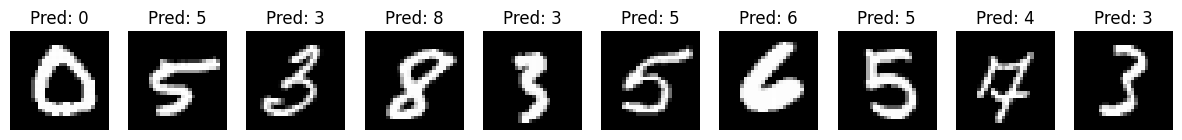

In [63]:
samples = X_test[530:540]

# Eğer samples DataFrame ise
if hasattr(samples, 'values'):
    samples = samples.values

z1, a1, z2, a2 = forward_propagation(samples, w1, b1, w2, b2)
predictions = np.argmax(a2, axis=1)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f'Pred: {predictions[i]}')

plt.show()


In [58]:
def test_accuracy(X_test, y_test, w1, b1, w2, b2):
    z1, a1, z2, a2 = forward_propagation(X_test, w1, b1, w2, b2)
    loss = compute_loss(y_test, a2)
    y_pred = np.argmax(a2, axis=1)
    y_true = np.argmax(y_test, axis=1)
    accuracy = np.mean(y_pred == y_true)
    print(f"Test Loss: {loss:.4f} - Test Accuracy: {accuracy:.4f}")
    return loss, accuracy


In [59]:
test_accuracy(X_val, y_val, w1, b1, w2, b2)

Test Loss: 0.2398 - Test Accuracy: 0.9312


(np.float64(0.23978750056715134), np.float64(0.9311904761904762))